In [1]:

import pandas as pd
import numpy as np
import nflreadpy as nfl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import KFold
from scipy.stats import poisson
from statsmodels.discrete.discrete_model import GeneralizedPoisson # Not gonna use it but its a little better
from sklearn.utils import resample

# I like to have the okabe ito colors, sort of 

from okabeito import lightblue, yellow, orange, green, purple, red, blue, black


In [2]:
pbp_pass = nfl.load_pbp(list(range(2006,2024))).to_pandas()

In [34]:
pbp_pass = pbp_pass.query("passer_id.notnull()").reset_index(drop=True)


pbp_pass.loc[pbp_pass.pass_touchdown.isnull(),"pass_touchdown"] = 0
pbp_pass.loc[pbp_pass.passer.isnull(),"passer"] = "none"


pbp_pass["team_spread"] = np.where(pbp_pass["posteam_type"] == "home",pbp_pass["spread_line"],-pbp_pass["spread_line"])


qb_game = (
    pbp_pass
    .groupby(["season","week","passer_id","passer"])
    .agg(pass_td = ('pass_touchdown',"sum"),
        n_passes = ('pass_touchdown','count'),
        total_line = ('total_line','first'),
        team_line =  ('team_spread','first'),
        air_yards= ("air_yards","sum"),
        interceptions = ("interception","sum"),
        completions = ("complete_pass","sum"),
        passing_yards = ("passing_yards","sum"),
        posteam_type = ("posteam_type","first"),
        season_type = ("season_type","first") )
    .reset_index()
    .query("n_passes >= 10")

)



In [41]:
rows = []
for season_idx in range(2006,2024):
    for week_idx in range(1,23):

        #mask = (qb_game["season"] == season_idx - 1) | ( (qb_game["season"] == season_idx) & (qb_game["week"] < week_idx))

        mask = (
            (qb_game["season"] == season_idx - 1) |
            ((qb_game["season"] == season_idx) &
            (qb_game["week"] < week_idx))
        )

        filtered_qb_game = (
            qb_game.loc[mask]
            .groupby(['passer_id',"passer"])
            .agg(n_games = ("pass_td","count"),
                 pass_td_rate = ("pass_td","mean"),
                 air_yards_pg = ("air_yards","mean"),
                 inteceptions_pg = ("interceptions","mean"),
                 completions_pg = ("completions","mean"),
                 passing_yards_pg = ("passing_yards","mean"))
            .reset_index()
            .assign(season = season_idx,week=week_idx))
        
        rows.append(filtered_qb_game) 

x_features = pd.concat(rows,ignore_index=True)





In [42]:
x_features

,passer_id,passer,n_games,pass_td_rate,air_yards_pg,inteceptions_pg,completions_pg,passing_yards_pg,season,week
0,00-0000865,C.Batch,1,3.000000,233.000000,0.000000,15.000000,209.000000,2006,2
1,00-0001361,D.Bledsoe,1,1.000000,304.000000,3.000000,16.000000,246.000000,2006,2
2,00-0001823,A.Brooks,1,0.000000,144.000000,0.000000,6.000000,68.000000,2006,2
3,00-0002110,M.Brunell,1,0.000000,174.000000,0.000000,17.000000,163.000000,2006,2
4,00-0003292,K.Collins,1,0.000000,291.000000,2.000000,17.000000,223.000000,2006,2
...,...,...,...,...,...,...,...,...,...,...
28705,00-0038598,J.Hall,1,0.000000,113.000000,1.000000,5.000000,67.000000,2023,22
28706,00-0039150,B.Young,16,0.687500,250.562500,0.625000,19.687500,179.812500,2023,22
28707,00-0039152,W.Levis,8,1.000000,322.750000,0.500000,18.375000,224.000000,2023,22
28708,00-0039163,C.Stroud,17,1.529412,288.882353,0.294118,20.823529,268.058824,2023,22


In [51]:
rolling_features_df = (
    qb_game.query("season >= 2007")
    .merge(x_features,on = ["season","week","passer_id","passer"],how="inner")
    .sort_values(["season","week","passer_id"])
)

In [52]:
rolling_features_df["is_home"] = (rolling_features_df["posteam_type"] == "home").astype(int)
rolling_features_df["is_playoff"] = (rolling_features_df["season_type"] == "POST").astype(int)


In [46]:
qb_game.groupby("pass_td").size()

pass_td
0.0    2410
1.0    3492
2.0    2571
3.0    1188
4.0     399
5.0      75
6.0      17
7.0       3
dtype: int64

In [53]:
rolling_features_df

,season,week,passer_id,passer,pass_td,n_passes,total_line,team_line,air_yards,interceptions,...,posteam_type,season_type,n_games,pass_td_rate,air_yards_pg,inteceptions_pg,completions_pg,passing_yards_pg,is_home,is_playoff
0,2007,1,00-0004161,J.Delhomme,3.0,30,43.0,-1.5,229.0,0.0,...,away,REG,13,1.307692,263.384615,0.846154,20.230769,215.769231,0,0
1,2007,1,00-0005106,B.Favre,0.0,47,41.5,-3.0,421.0,1.0,...,home,REG,16,1.125000,331.562500,1.125000,21.437500,242.812500,1,0
2,2007,1,00-0005755,J.Garcia,0.0,34,40.5,-6.0,226.0,0.0,...,away,REG,8,1.500000,274.125000,0.250000,18.375000,209.125000,0,0
3,2007,1,00-0006355,T.Green,1.0,42,34.0,-3.0,248.0,0.0,...,away,REG,9,0.888889,199.555556,1.222222,15.000000,161.000000,0,0
4,2007,1,00-0007091,M.Hasselbeck,1.0,28,40.5,6.0,192.0,0.0,...,home,REG,14,1.500000,320.357143,1.285714,17.571429,205.500000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276,2023,21,00-0033873,P.Mahomes,1.0,50,44.0,-4.5,233.0,0.0,...,away,POST,38,2.052632,254.368421,0.684211,24.947368,279.289474,0,1
9277,2023,21,00-0034796,L.Jackson,1.0,47,44.0,4.5,344.0,1.0,...,home,POST,28,1.535714,240.857143,0.500000,18.678571,216.464286,1,1
9278,2023,21,00-0037834,B.Purdy,1.0,36,52.5,7.5,283.0,1.0,...,home,POST,26,1.846154,218.884615,0.576923,18.538462,248.153846,1,1
9279,2023,22,00-0033873,P.Mahomes,2.0,55,47.0,-1.5,280.0,1.0,...,home,POST,39,2.025641,253.820513,0.666667,25.076923,278.307692,1,1


In [67]:
X_base = rolling_features_df[["pass_td_rate","total_line"]].values
y = rolling_features_df["pass_td"].values


model_simple_full = PoissonRegressor(alpha=0,max_iter=1000)

model_simple_full.fit(X_base,y)




,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",0
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",True
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",1000
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


In [57]:
model_simple_full.coef_

array([0.30939192, 0.02309926])

In [68]:
obs_p = pd.Series(y)

<Axes: >

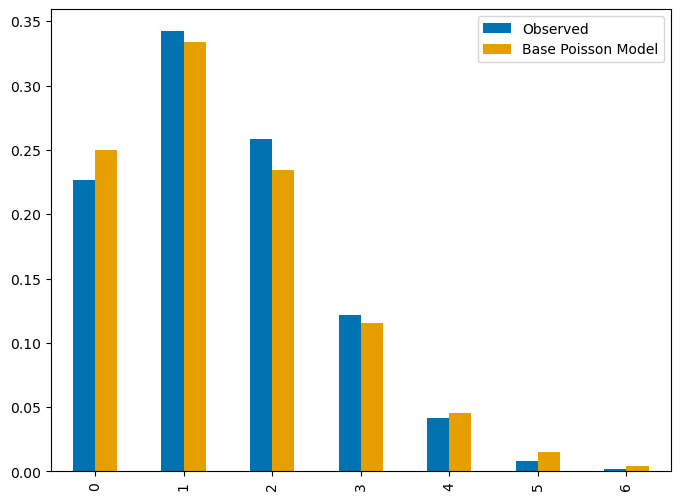

In [69]:
td_counts = np.arange(7)

mu = model_simple_full.predict(X_base)
probs = np.column_stack([poisson.pmf(k,mu)  for k in td_counts ])
marginal_probs = probs.mean(axis=0)
obs_p = pd.Series(y).value_counts(normalize=True).sort_index()





count_df = pd.DataFrame({
    "Observed":[obs_p.get(k,0) for k in td_counts],
    "Base Poisson Model": marginal_probs
})

count_df.plot.bar(color=[blue,orange],figsize=(8,6))










In [72]:
kf_random = KFold(n_splits=5, shuffle=True,random_state=65)


pw_all = []


for tr, te in kf_random.split(X_base):
    model_basic = PoissonRegressor(alpha=0, max_iter=1000)
    model_basic.fit(X_base[tr],y[tr])
    mu = model_basic.predict(X_base[te])
    score = poisson.logpmf(y[te],mu)
    pw_all.append(score)

pw_all = np.concatenate(pw_all)
    



In [73]:
pw_all.mean()

np.float64(-1.4544564601835692)

In [74]:
rolling_features_df

,season,week,passer_id,passer,pass_td,n_passes,total_line,team_line,air_yards,interceptions,...,posteam_type,season_type,n_games,pass_td_rate,air_yards_pg,inteceptions_pg,completions_pg,passing_yards_pg,is_home,is_playoff
0,2007,1,00-0004161,J.Delhomme,3.0,30,43.0,-1.5,229.0,0.0,...,away,REG,13,1.307692,263.384615,0.846154,20.230769,215.769231,0,0
1,2007,1,00-0005106,B.Favre,0.0,47,41.5,-3.0,421.0,1.0,...,home,REG,16,1.125000,331.562500,1.125000,21.437500,242.812500,1,0
2,2007,1,00-0005755,J.Garcia,0.0,34,40.5,-6.0,226.0,0.0,...,away,REG,8,1.500000,274.125000,0.250000,18.375000,209.125000,0,0
3,2007,1,00-0006355,T.Green,1.0,42,34.0,-3.0,248.0,0.0,...,away,REG,9,0.888889,199.555556,1.222222,15.000000,161.000000,0,0
4,2007,1,00-0007091,M.Hasselbeck,1.0,28,40.5,6.0,192.0,0.0,...,home,REG,14,1.500000,320.357143,1.285714,17.571429,205.500000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276,2023,21,00-0033873,P.Mahomes,1.0,50,44.0,-4.5,233.0,0.0,...,away,POST,38,2.052632,254.368421,0.684211,24.947368,279.289474,0,1
9277,2023,21,00-0034796,L.Jackson,1.0,47,44.0,4.5,344.0,1.0,...,home,POST,28,1.535714,240.857143,0.500000,18.678571,216.464286,1,1
9278,2023,21,00-0037834,B.Purdy,1.0,36,52.5,7.5,283.0,1.0,...,home,POST,26,1.846154,218.884615,0.576923,18.538462,248.153846,1,1
9279,2023,22,00-0033873,P.Mahomes,2.0,55,47.0,-1.5,280.0,1.0,...,home,POST,39,2.025641,253.820513,0.666667,25.076923,278.307692,1,1


In [86]:
feature_sets = {
    "Basic":  ["pass_td_rate","total_line"],
    "Betting Only": ["total_line","team_line"],
    "Throwing Focus":  ["pass_td_rate", "completions_pg","air_yards_pg","passing_yards_pg","inteceptions_pg"],
    "Situation Focused":  ["total_line", "team_line", "is_home","is_playoff","week"],
    "Everything": ["pass_td_rate", "total_line", "completions_pg","air_yards_pg","passing_yards_pg","inteceptions_pg","team_line", "is_home","is_playoff","n_games","week"],
    "My Best Idea": ["pass_td_rate","total_line","team_line","is_home","air_yards_pg","completions_pg","passing_yards_pg"]
}

In [87]:
cv_results = {}

kf_random = KFold(n_splits=10,shuffle=True,random_state=65)

for name, cols in feature_sets.items():
    Xm = rolling_features_df[cols].values
    pw_all = []


    for tr, te in kf_random.split(Xm):
        model = PoissonRegressor(alpha=0,max_iter=10000)
        model.fit(Xm[tr],y[tr])
        yhat = model.predict(Xm[te])
        ll = poisson.logpmf(y[te],yhat)
        pw_all.append(ll)

    pw_all = np.concatenate(pw_all)
    cv_results[name] = dict(
        mean_ll = pw_all.mean(),
        se_ll = np.std(pw_all,ddof=1)/np.sqrt(len(pw_all))
    )


cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.index.name="model"

In [88]:
cv_results_df

,mean_ll,se_ll
model,,
Basic,-1.454445,0.005925
Betting Only,-1.450535,0.005864
Throwing Focus,-1.455796,0.005962
Situation Focused,-1.450459,0.005870
Everything,-1.441884,0.005885
My Best Idea,-1.443056,0.005864


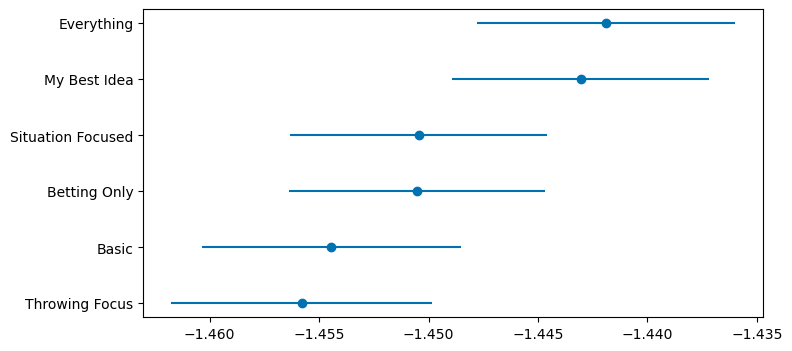

In [ ]:
df_sorted = cv_results_df.sort_values("mean_ll",ascending=False)


fig, ax = plt.subplots(figsize=(8,4))
y_pos = range(len(df_sorted))

ax.errorbar(df_sorted["mean_ll"],y_pos,xerr=df_sorted["se_ll"],fmt='o',color=blue)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted.index)


ax.invert_yaxis()
plt.tight_layout()
plt.show()


